# AAX, Seminar 4: Wi-Fi Performance Prediction with Neural Networks

**Author:** Melker Svensson, Felipe Lopez, Raul 

## Problem statement

We revisit the Wi-Fi performance prediction problem from Seminar 1, but this time we will solve it with a Feedforward Neural Network (FNN) instead of a linear regression. The dataset contains Wi-Fi measurements taken from real residential networks during one month, split into `train_data.csv` and `test_data.csv`.

**Features**
* `LocationNumber`, zone where the measurement was taken (categorical, up to 35).
* `RSSI`, received signal strength.
* `TxLinkSpeed`, downlink link speed (AP to STA).
* `RxLinkSpeed`, uplink link speed (STA to AP).
* `MainAPConnect`, binary, 1 if connected to the main AP, 0 if connected to an extender.

**Targets (performance metrics)**
* `TxThroughput`, achieved throughput.
* `AvgPingLatency`, average ping latency to a server.

## Part I, Data preparation and analysis

In this first part we explore the dataset to understand its structure, the distribution of each feature, and the relationships between features and performance metrics. This insight will drive feature selection and preprocessing in Part II.

### 1. Imports and configuration

We use `pandas` for tabular handling, `numpy` for numerics, and `matplotlib` plus `seaborn` for visualisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

### 2. Load the dataset

We load the train and test CSV files. For exploration we mostly use the training set, the test set is kept untouched and only used in Part II for the final evaluation.

In [2]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test  shape: {test_df.shape}")
train_df.head()

Train shape: (33600, 7)
Test  shape: (8400, 7)


,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,2,-72.320,163.110,118.360,1,13.510,51.790
1,32,-73.180,238.450,212.830,1,3.350,68.800
2,20,-40.670,865.440,863.390,1,17.620,50.790
3,10,-60.660,473.890,396.920,1,14.300,64.150
4,29,-67.960,479.740,355.990,1,4.810,73.810


### 3. Basic structure and data quality

We check column types, missing values, and duplicates. Clean data is a prerequisite before fitting a neural network. NaNs or extreme outliers can destabilise training for neural setups.

In [6]:
# column types
train_df.dtypes

LocationNumber      int64
RSSI              float64
TxLinkSpeed       float64
RxLinkSpeed       float64
MainAPConnect       int64
TxThroughput      float64
AvgPingLatency    float64
dtype: object

In [7]:
# missing values per column
train_df.isna().sum()

LocationNumber    0
RSSI              0
TxLinkSpeed       0
RxLinkSpeed       0
MainAPConnect     0
TxThroughput      0
AvgPingLatency    0
dtype: int64

In [5]:
# duplicated rows
print(f"Duplicated rows in train: {train_df.duplicated().sum()}")
print(f"Duplicated rows in test : {test_df.duplicated().sum()}")

Duplicated rows in train: 0
Duplicated rows in test : 0


No NaNs, no duplicates and data types are alredy numeric. Great :) 

### 4. Descriptive statistics

`describe()` gives us mean, std, min, quartiles and max for every numeric column. This is the quickest way to spot suspicious ranges (e.g., negative throughput) and to get a feel for the scale of each feature, which matters later for normalisation.

In [8]:
train_df.describe()

,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
count,"33,600.000","33,600.000","33,600.000","33,600.000","33,600.000","33,600.000","33,600.000"
mean,18.151,-62.364,491.265,460.954,0.914,12.989,54.771
std,10.338,9.442,240.869,251.600,0.280,4.414,8.736
min,1.000,-79.040,33.240,-12.530,0.000,0.780,39.300
25%,9.000,-70.360,273.200,249.127,1.000,11.320,48.940
50%,18.000,-62.910,476.635,396.480,1.000,14.790,52.290
75%,27.000,-53.790,664.390,656.422,1.000,15.980,57.470
max,36.000,-37.020,905.390,911.000,1.000,19.160,96.550


### 5. Distribution of each feature and target

Histograms reveal the shape of each variable, useful to detect skew, multimodality or hard limits. For neural networks, very skewed inputs or targets often benefit from a log transform or robust scaling.

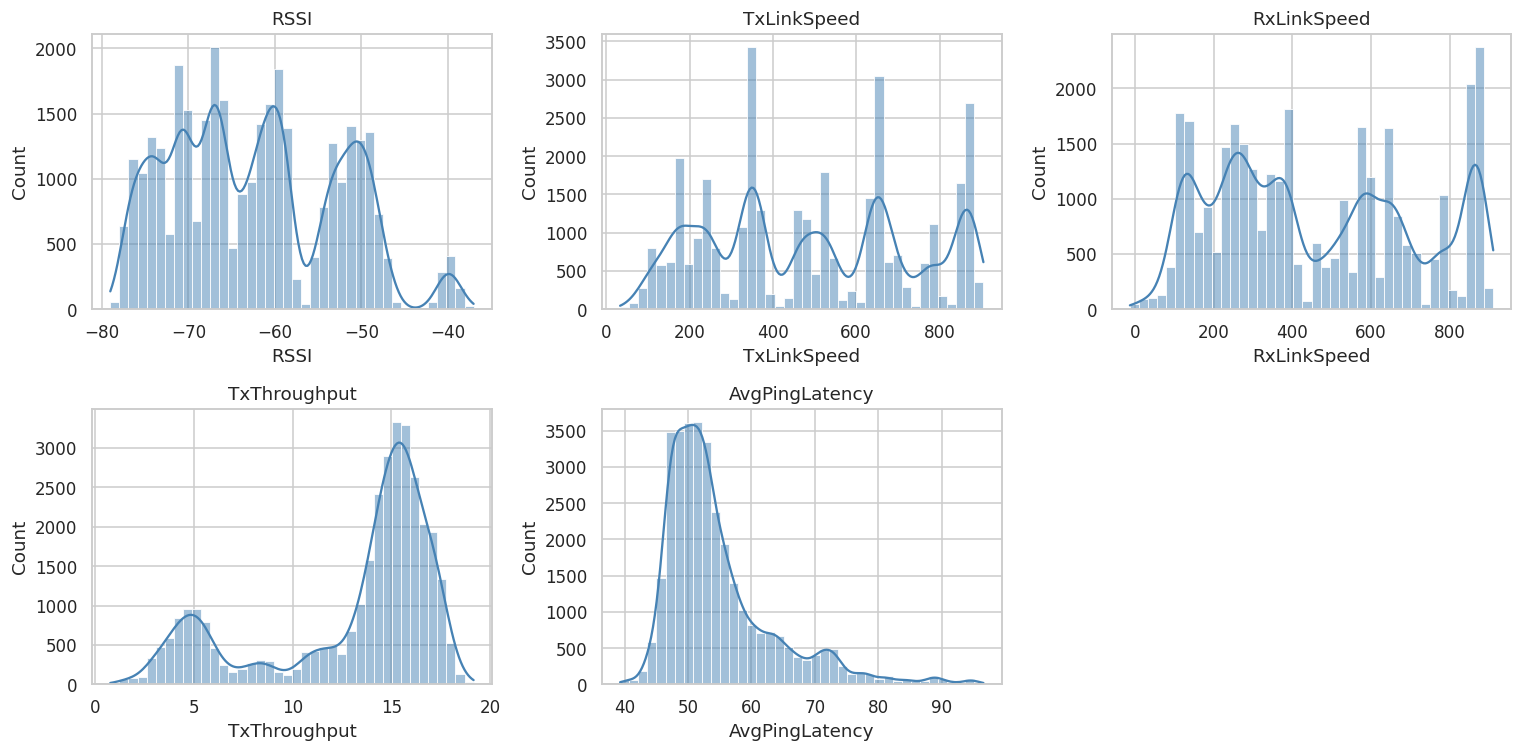

In [9]:
numeric_cols = ["RSSI", "TxLinkSpeed", "RxLinkSpeed", "TxThroughput", "AvgPingLatency"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(train_df[col], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

No skewed distributions, however Tx/RxLinkSpeed on the x-axis have big ranges and large values. They also don't seem to follow a very defined distribution, with relatively concentrated discrete values. 

### 6. Categorical and binary features

`LocationNumber` is categorical (zone id, up to 35) and `MainAPConnect` is binary. We look at their value counts to check class balance, an imbalanced binary feature, for example, would limit how informative it is for the model.

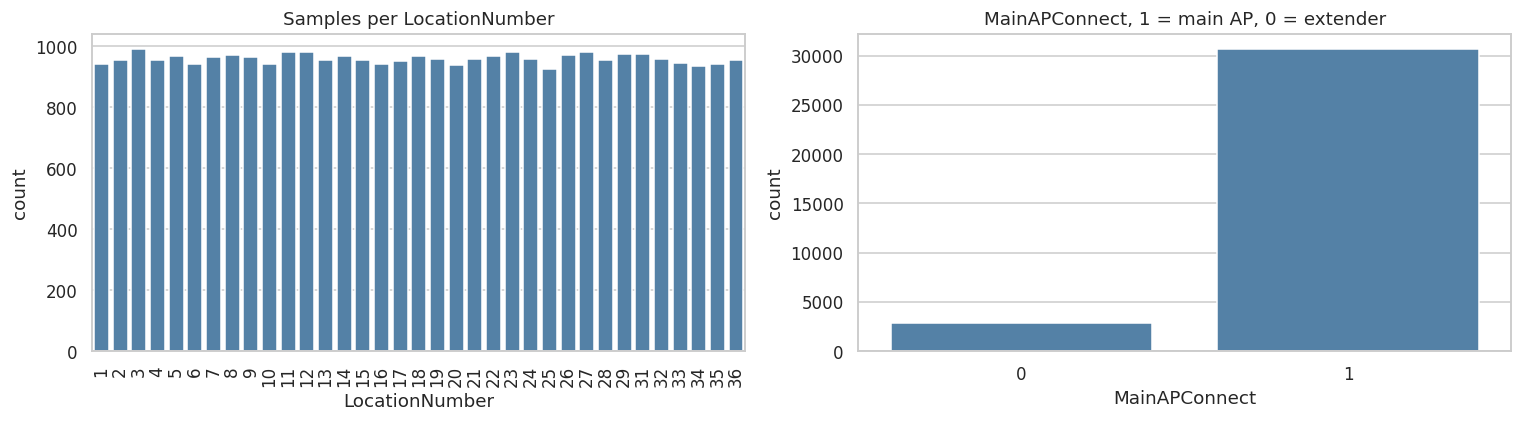

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x="LocationNumber", data=train_df, ax=axes[0], color="steelblue")
axes[0].set_title("Samples per LocationNumber")
axes[0].tick_params(axis="x", rotation=90)

sns.countplot(x="MainAPConnect", data=train_df, ax=axes[1], color="steelblue")
axes[1].set_title("MainAPConnect, 1 = main AP, 0 = extender")

plt.tight_layout()
plt.show()

There is no class imbalance, all location numbers have roughly the same number of entries. However, MainAPConnect is very skewed, with far more points being connected to the AP (1) rather than the extender (0).

### 7. Boxplots, outlier check and effect of MainAPConnect

Boxplots highlight outliers in the numeric features. We also split the performance metrics by `MainAPConnect` to see whether being connected directly to the main AP changes throughput or latency, which is a strong prior in Wi-Fi networks.

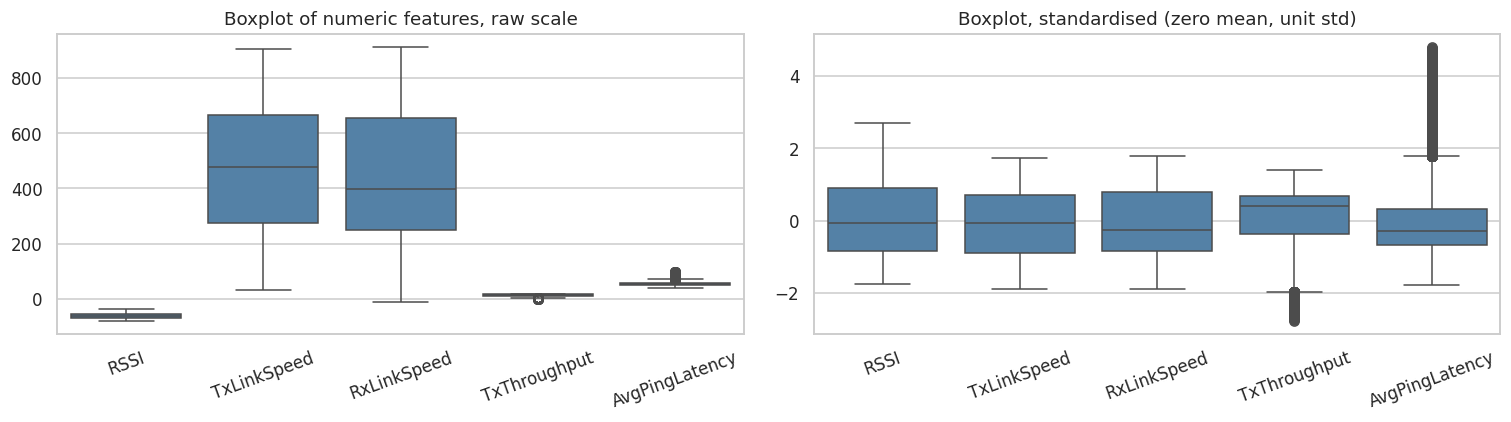

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=train_df[numeric_cols], ax=axes[0], color="steelblue")
axes[0].set_title("Boxplot of numeric features, raw scale")
axes[0].tick_params(axis="x", rotation=20)

# same boxplot, but standardised so all variables are visible together
standardised = (train_df[numeric_cols] - train_df[numeric_cols].mean()) / train_df[numeric_cols].std()
sns.boxplot(data=standardised, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot, standardised (zero mean, unit std)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Here we observe the same thing we noticed with the histograms. There is no direct outlier, and the xLinkSpeed are the features with more range. As expected, after standerization they all look quite similar. 

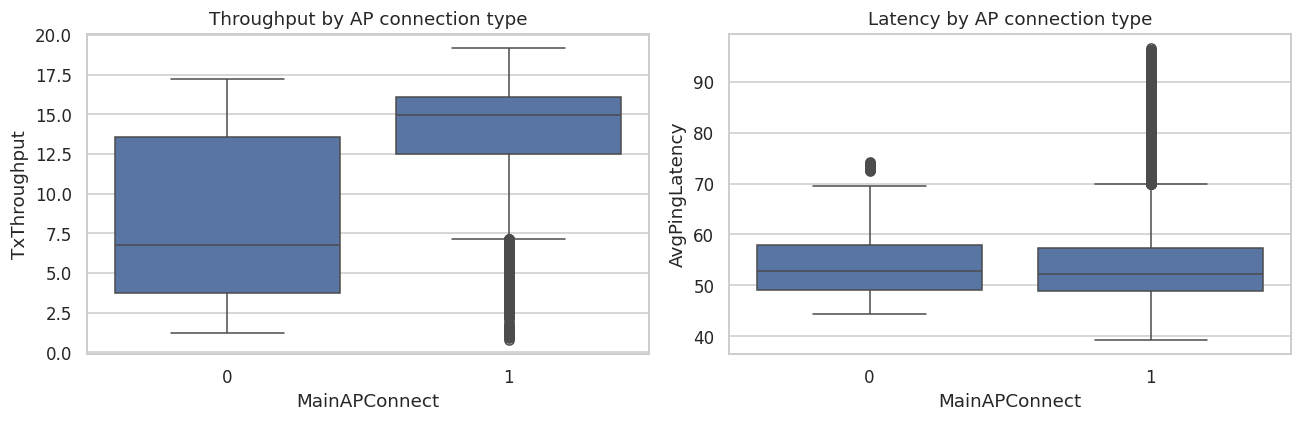

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="MainAPConnect", y="TxThroughput", data=train_df, ax=axes[0])
axes[0].set_title("Throughput by AP connection type")
sns.boxplot(x="MainAPConnect", y="AvgPingLatency", data=train_df, ax=axes[1])
axes[1].set_title("Latency by AP connection type")
plt.tight_layout()
plt.show()

Here we can easily see that being connected to the Extender (0) clearly affects positively the throughput, with devices connected to this on average having much better throughput and less range/varaibility in the boxplot. 

However, being connected to AP (1) or Extender (0) does not affect Latency, which is similar in both.  

### 8. Performance per location

We aggregate throughput and latency by `LocationNumber` to see whether the zone has a strong effect on performance. If the spread across zones is wide, `LocationNumber` will be a valuable categorical input for the FNN (one-hot encoded).

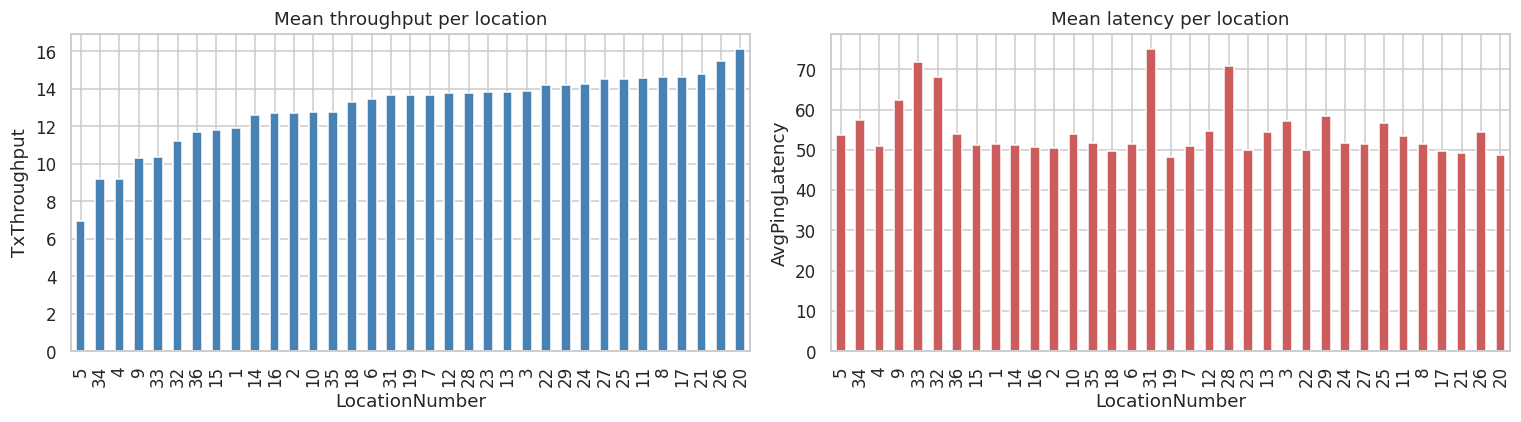

In [13]:
loc_stats = train_df.groupby("LocationNumber")[["TxThroughput", "AvgPingLatency"]].mean().sort_values("TxThroughput")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
loc_stats["TxThroughput"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Mean throughput per location")
axes[0].set_ylabel("TxThroughput")

loc_stats["AvgPingLatency"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Mean latency per location")
axes[1].set_ylabel("AvgPingLatency")
plt.tight_layout()
plt.show()

We can clearly see that locationNumber is a strong indication of performance on throughput, some locations on average has noticebly worse throughput than others. Such as 5 which on average has 6 while 20 has 16, a whole 10 point difference. 

Meanwhile locationNumber and latency correlation is less straight forward, with a lot of locations having similar values. However, there are also some outliers here. 

### 9. Correlation analysis

We compute the Pearson correlation matrix between all numeric variables. Pearson captures linear relationships; we add Spearman afterwards to also catch monotonic non,linear ones, which is relevant because neural networks can exploit non,linear dependencies.

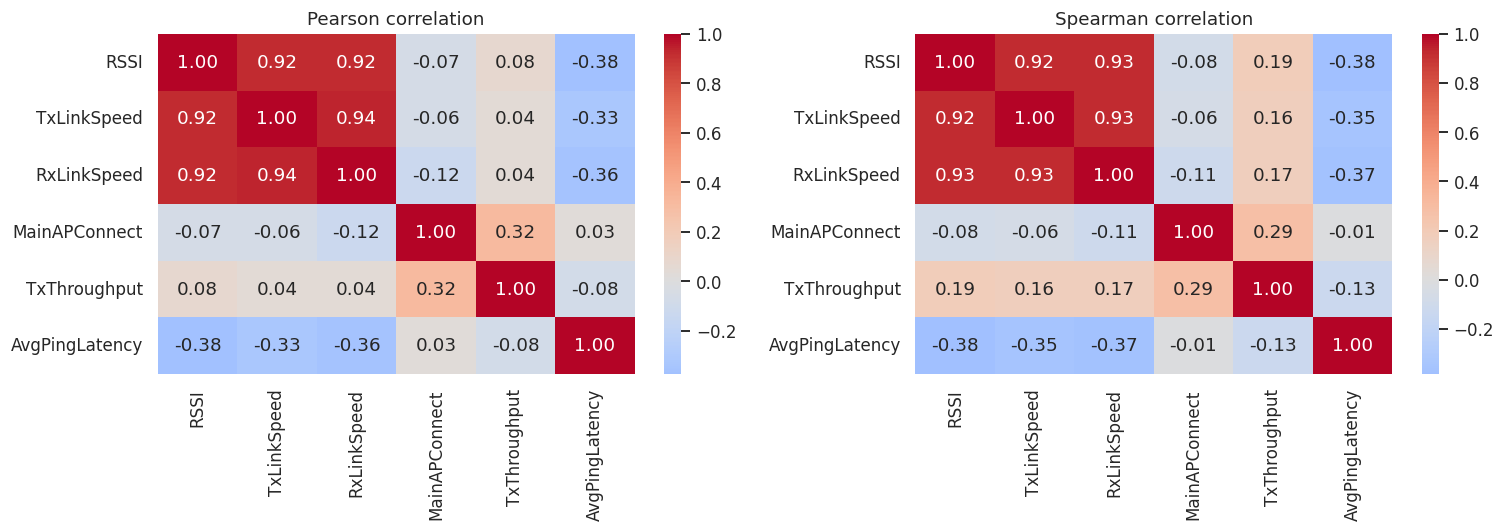

In [14]:
corr_cols = ["RSSI", "TxLinkSpeed", "RxLinkSpeed", "MainAPConnect", "TxThroughput", "AvgPingLatency"]

pearson_corr = train_df[corr_cols].corr(method="pearson")
spearman_corr = train_df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

Person and Spearman are very similar, indicating that the correlations we observe are linear. For the two target labels we see the following:
- TxThroughput: correlates the highest with MainApConnect (0.32) 
- AvgPingLatency: correlates the highest with MainApConnect (0.03)

In general these results show us that there is no strong correlation between features and target labels, indicating that the neural network is going to have to learn complex and non-trivial relationships between input feature space and outputs. 

### 12. Summary of Part I

Key observations from the exploratory analysis:

* **Data quality**, the dataset is clean, no missing values worth noting, and feature scales differ widely (RSSI in dB, link speeds in hundreds, throughput and latency in tens). Normalisation will therefore be necessary before training the FNN.
* **RSSI and link speeds**, these tend to correlate with throughput (higher signal, higher link speed, higher throughput), confirming the physical intuition.
* **MainAPConnect**, clients on the main AP usually show better throughput and lower latency than those on an extender.
* **LocationNumber**, performance varies noticeably across zones, so the location is a meaningful categorical predictor and should be one,hot encoded for the FNN.
* **Relationships are not purely linear**, scatter plots show saturation and heteroscedastic noise, which justifies using a non,linear model like an FNN over a simple linear regression.

These findings will guide the feature selection, preprocessing and architecture design in Part II.